In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:

# Load datasets
train = pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\Dataset\train.csv", low_memory=False)
test = pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\Dataset\test.csv", low_memory=False)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (1017209, 9)
Test shape: (41088, 8)


In [6]:
print("\nTrain columns:", list(train.columns))
print("\nTest columns:", list(test.columns))

display(train.head())
print("\nMissing values:\n", train.isnull().sum())



Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Test columns: ['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



Missing values:
 Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [7]:
# Drop rows where store was closed (Open == 0) since sales = 0 then
train = train[train["Open"] == 1]

# Fill missing 'Open' values in test with 1 (assume open)
test["Open"].fillna(1, inplace=True)

print("Train shape after cleaning:", train.shape)


Train shape after cleaning: (844392, 9)


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3366711883.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Open"].fillna(1, inplace=True)


In [8]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day

test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Day'] = test['Date'].dt.day

train.drop('Date', axis=1, inplace=True)
test.drop('Date', axis=1, inplace=True)

train.head()


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day
0,1,5,5263,555,1,1,0,1,2015,7,31
1,2,5,6064,625,1,1,0,1,2015,7,31
2,3,5,8314,821,1,1,0,1,2015,7,31
3,4,5,13995,1498,1,1,0,1,2015,7,31
4,5,5,4822,559,1,1,0,1,2015,7,31


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['StateHoliday'] = le.fit_transform(train['StateHoliday'])
test['StateHoliday'] = le.transform(test['StateHoliday'])

print("Categorical encoding done.")


Categorical encoding done.


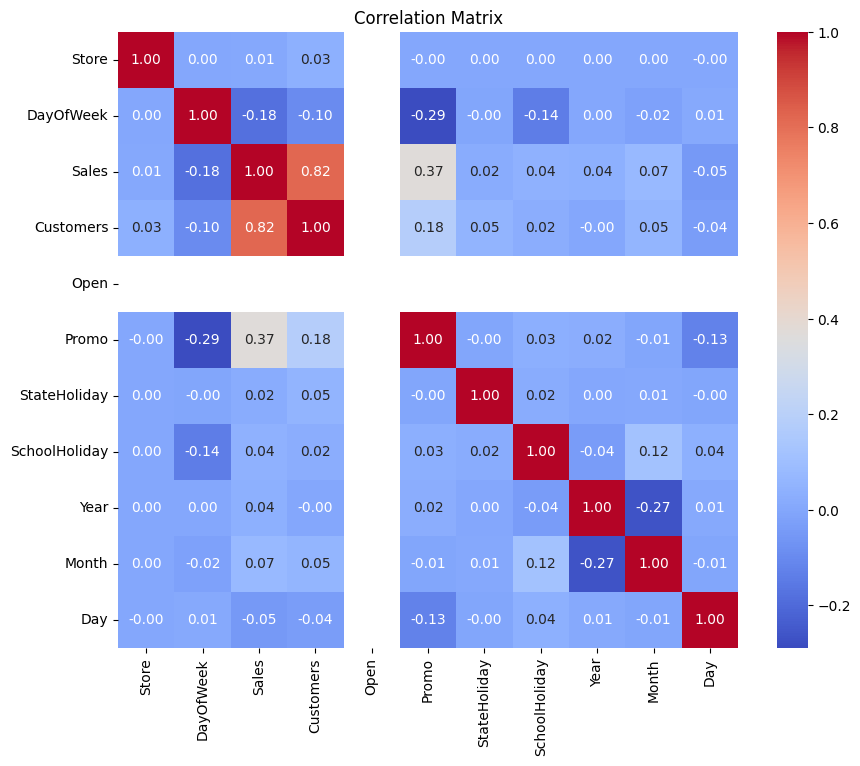

In [10]:
# Import seaborn if not already
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation
corr = train.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()





In [11]:
# Inspect column names and first few rows to understand dataset structure
print("🧾 Columns in training dataset:")
print(train.columns.tolist())

print("\n🔍 Dataset information:")
print(train.info())

print("\n📊 First 5 rows:")
display(train.head())

# Check for missing values
print("\n❗ Missing values per column:")
print(train.isnull().sum())



🧾 Columns in training dataset:
['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day']

🔍 Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Store          844392 non-null  int64
 1   DayOfWeek      844392 non-null  int64
 2   Sales          844392 non-null  int64
 3   Customers      844392 non-null  int64
 4   Open           844392 non-null  int64
 5   Promo          844392 non-null  int64
 6   StateHoliday   844392 non-null  int64
 7   SchoolHoliday  844392 non-null  int64
 8   Year           844392 non-null  int32
 9   Month          844392 non-null  int32
 10  Day            844392 non-null  int32
dtypes: int32(3), int64(8)
memory usage: 67.6 MB
None

📊 First 5 rows:


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day
0,1,5,5263,555,1,1,0,1,2015,7,31
1,2,5,6064,625,1,1,0,1,2015,7,31
2,3,5,8314,821,1,1,0,1,2015,7,31
3,4,5,13995,1498,1,1,0,1,2015,7,31
4,5,5,4822,559,1,1,0,1,2015,7,31



❗ Missing values per column:
Store            0
DayOfWeek        0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
Year             0
Month            0
Day              0
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3340835163.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='DayOfWeek', y='Sales', data=train, ci=None, palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3340835163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='Sales', data=train, ci=None, palette='viridis')


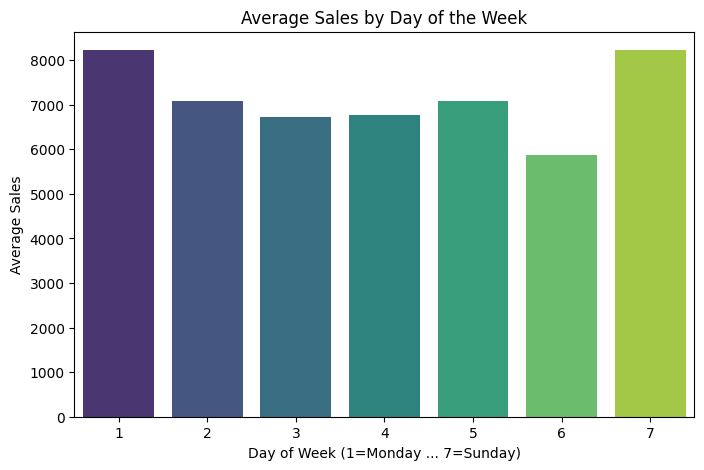

In [12]:


plt.figure(figsize=(8,5))
sns.barplot(x='DayOfWeek', y='Sales', data=train, ci=None, palette='viridis')
plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of Week (1=Monday ... 7=Sunday)")
plt.ylabel("Average Sales")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\2418480515.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Month', y='Sales', data=train, ci=None, palette='plasma')
C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\2418480515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Sales', data=train, ci=None, palette='plasma')


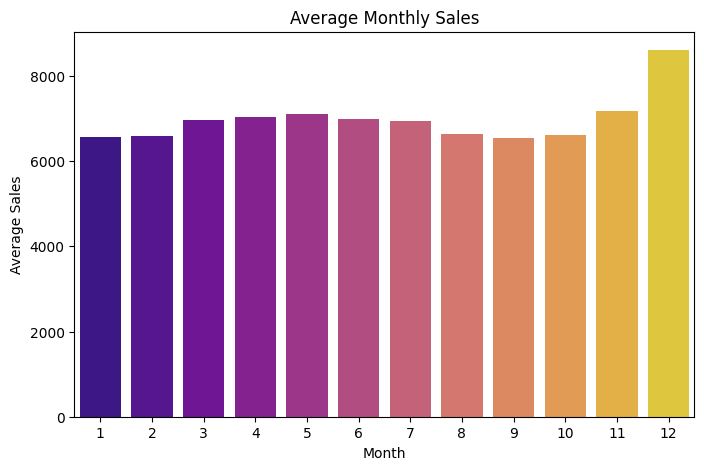

In [13]:


plt.figure(figsize=(8,5))
sns.barplot(x='Month', y='Sales', data=train, ci=None, palette='plasma')
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\497054790.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Promo', y='Sales', data=train, ci=None, palette='coolwarm')
C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\497054790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promo', y='Sales', data=train, ci=None, palette='coolwarm')


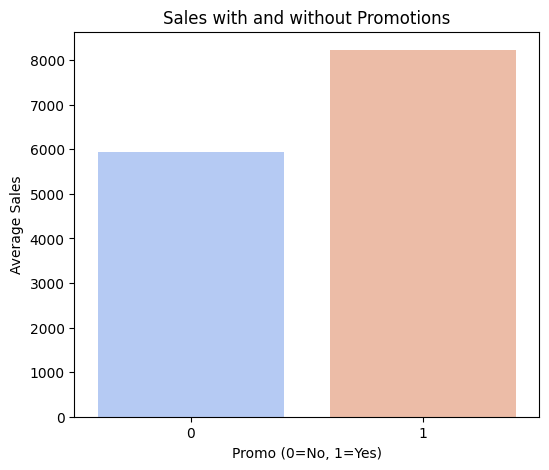

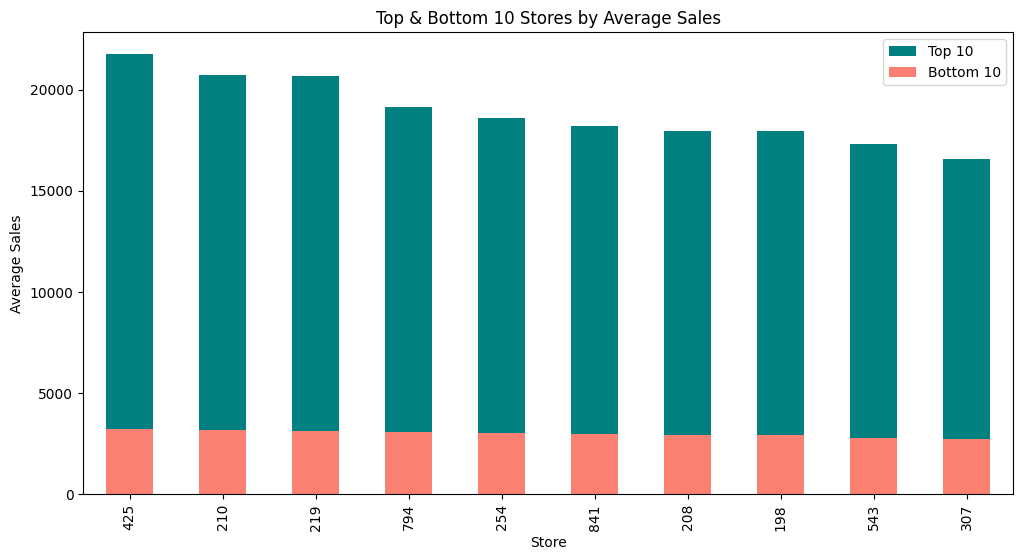

In [14]:

plt.figure(figsize=(6,5))
sns.barplot(x='Promo', y='Sales', data=train, ci=None, palette='coolwarm')
plt.title("Sales with and without Promotions")
plt.xlabel("Promo (0=No, 1=Yes)")
plt.ylabel("Average Sales")
plt.show()

store_sales = train.groupby('Store')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
store_sales[:10].plot(kind='bar', color='teal', label='Top 10')
store_sales[-10:].plot(kind='bar', color='salmon', label='Bottom 10')
plt.title("Top & Bottom 10 Stores by Average Sales")
plt.ylabel("Average Sales")
plt.legend()
plt.show()

In [15]:
X = train.drop(["Sales", "Customers"], axis=1)
y = train["Sales"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (844392, 9)
Target vector shape: (844392,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Validation:", X_val.shape)


Train: (675513, 9) Validation: (168879, 9)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

print(f"Linear Regression — RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")


Linear Regression — RMSE: 2864.08, R²: 0.149


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f}, R²: {r2_rf:.3f}")


Random Forest — RMSE: 1639.42, R²: 0.721


In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})
display(results)


,Model,RMSE,R2
0,Linear Regression,2864.077165,0.149405
1,Random Forest,1639.419933,0.721302


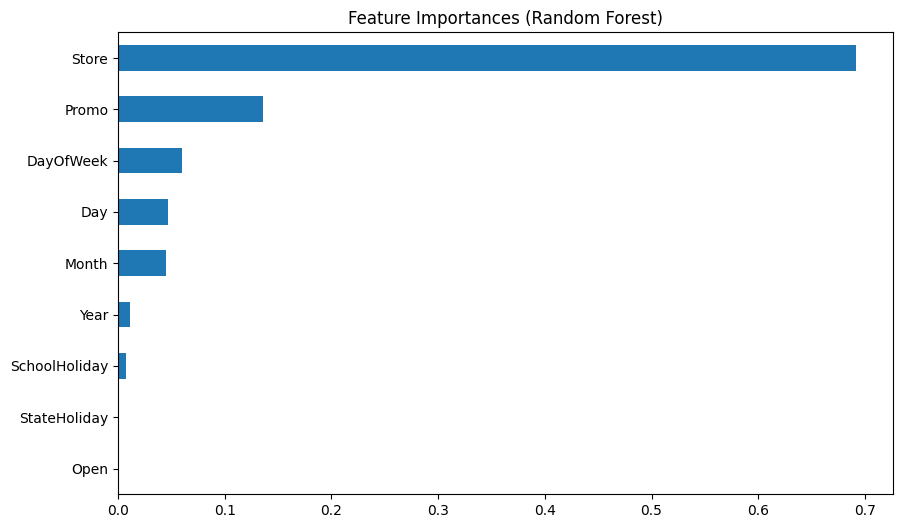

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title("Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [21]:
# Prepare test data for prediction
X_test = test.drop(["Id"], axis=1)

# Predict sales using the trained Random Forest model
test["Predicted_Sales"] = rf.predict(X_test)

# Sort by top performing stores
top_predictions = test.groupby("Store")["Predicted_Sales"].mean().sort_values(ascending=False).reset_index()

print("Top 5 stores predicted to sell the most:")
display(top_predictions.head())

print("\nLowest 5 stores predicted to sell the least:")
display(top_predictions.tail())


Top 5 stores predicted to sell the most:


,Store,Predicted_Sales
0,1114,22493.821250
1,262,19013.682083
2,251,16823.402500
3,562,15101.884375
4,756,14377.175625



Lowest 5 stores predicted to sell the least:


,Store,Predicted_Sales
851,520,4458.415208
852,210,4305.871875
853,897,4292.909583
854,435,4151.778333
855,219,3565.171042


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3648646140.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Month", y="Predicted_Sales", data=monthly_sales, palette="plasma")


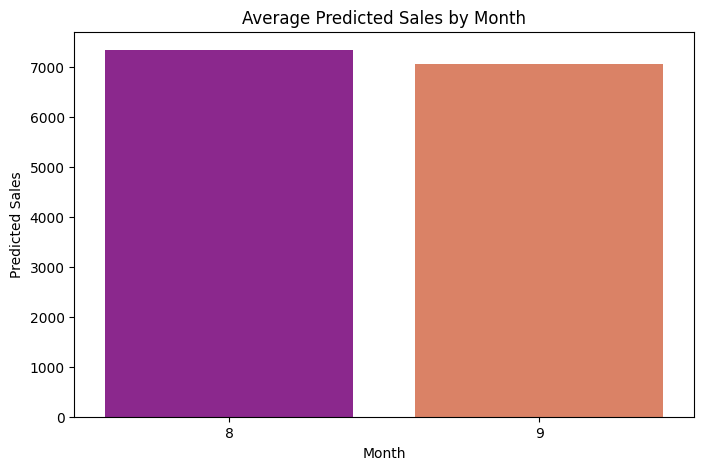

C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\3648646140.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="DayOfWeek", y="Predicted_Sales", data=dow_sales, palette="viridis")


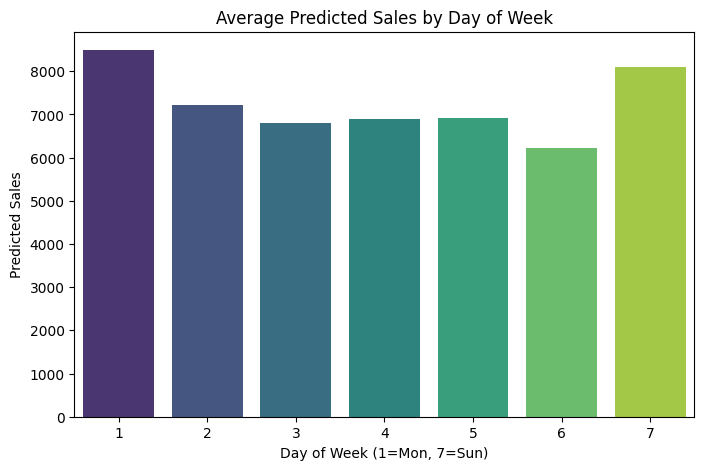

In [22]:
# Add Month and DayOfWeek back to analyze temporal patterns
test['Predicted_Sales'] = rf.predict(X_test)

# Average predicted sales per month
monthly_sales = test.groupby("Month")["Predicted_Sales"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Month", y="Predicted_Sales", data=monthly_sales, palette="plasma")
plt.title("Average Predicted Sales by Month")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.show()

# Average predicted sales by day of week
dow_sales = test.groupby("DayOfWeek")["Predicted_Sales"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="DayOfWeek", y="Predicted_Sales", data=dow_sales, palette="viridis")
plt.title("Average Predicted Sales by Day of Week")
plt.xlabel("Day of Week (1=Mon, 7=Sun)")
plt.ylabel("Predicted Sales")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\33507586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Store", y="Predicted_Sales", data=top_20, palette="coolwarm")


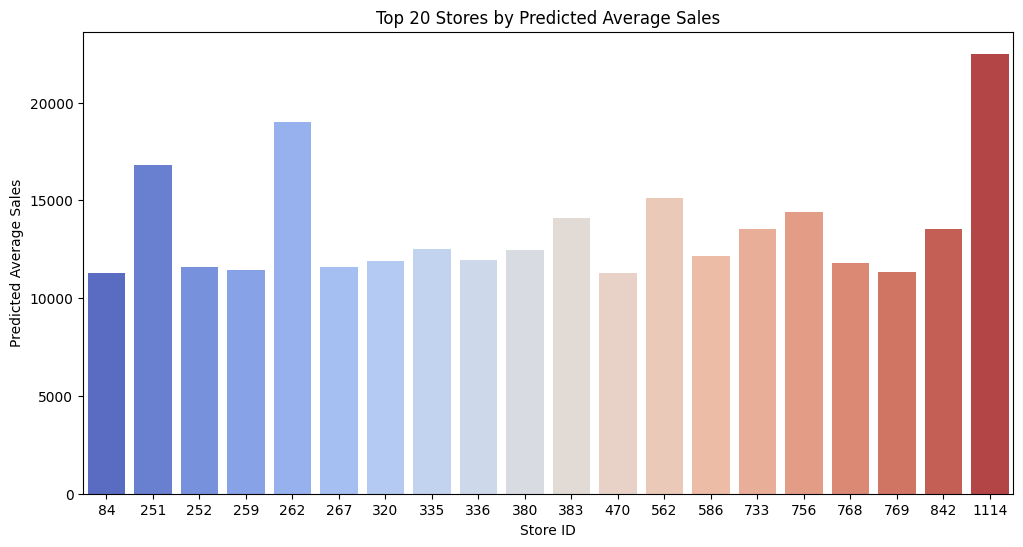

In [23]:
plt.figure(figsize=(12,6))
top_20 = top_predictions.head(20)
sns.barplot(x="Store", y="Predicted_Sales", data=top_20, palette="coolwarm")
plt.title("Top 20 Stores by Predicted Average Sales")
plt.xlabel("Store ID")
plt.ylabel("Predicted Average Sales")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\575533726.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Promo", y="Predicted_Sales", data=promo_effect, palette="magma")


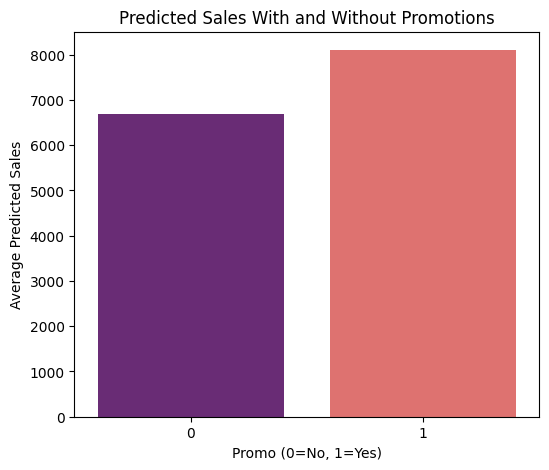

💡 Promotions are predicted to boost sales by approximately 21.27% on average.


In [24]:
promo_effect = test.groupby("Promo")["Predicted_Sales"].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x="Promo", y="Predicted_Sales", data=promo_effect, palette="magma")
plt.title("Predicted Sales With and Without Promotions")
plt.xlabel("Promo (0=No, 1=Yes)")
plt.ylabel("Average Predicted Sales")
plt.show()

increase = (promo_effect.loc[promo_effect["Promo"]==1, "Predicted_Sales"].values[0] /
            promo_effect.loc[promo_effect["Promo"]==0, "Predicted_Sales"].values[0] - 1) * 100

print(f"💡 Promotions are predicted to boost sales by approximately {increase:.2f}% on average.")


In [25]:
best_month = int(monthly_sales.loc[monthly_sales["Predicted_Sales"].idxmax(), "Month"])
best_day = int(dow_sales.loc[dow_sales["Predicted_Sales"].idxmax(), "DayOfWeek"])
best_store = int(top_predictions.iloc[0]["Store"])

print(f"🧾 Model Insights Summary:")
print(f"- Best month for sales: Month {best_month}")
print(f"- Best day for sales: Day {best_day} (1=Monday ... 7=Sunday)")
print(f"- Store expected to perform best: Store {best_store}")
print(f"- Promotion boosts average sales by about {increase:.2f}%")


🧾 Model Insights Summary:
- Best month for sales: Month 8
- Best day for sales: Day 1 (1=Monday ... 7=Sunday)
- Store expected to perform best: Store 1114
- Promotion boosts average sales by about 21.27%


c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


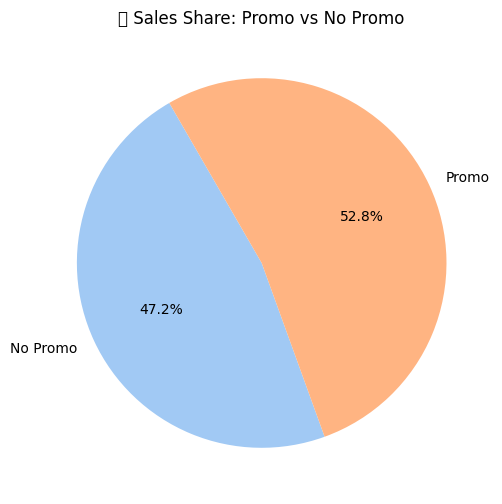

In [26]:
plt.figure(figsize=(6,6))
promo_sales = train.groupby("Promo")["Sales"].sum()
plt.pie(promo_sales, labels=["No Promo", "Promo"], autopct="%1.1f%%", startangle=120, colors=sns.color_palette("pastel"))
plt.title("🥧 Sales Share: Promo vs No Promo")
plt.show()


c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


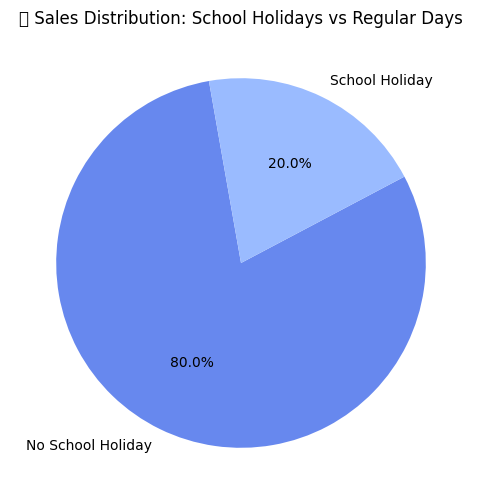

In [27]:
plt.figure(figsize=(6,6))
school_sales = train.groupby("SchoolHoliday")["Sales"].sum()
plt.pie(school_sales, labels=["No School Holiday", "School Holiday"], autopct="%1.1f%%", startangle=100, colors=sns.color_palette("coolwarm"))
plt.title("🎓 Sales Distribution: School Holidays vs Regular Days")
plt.show()


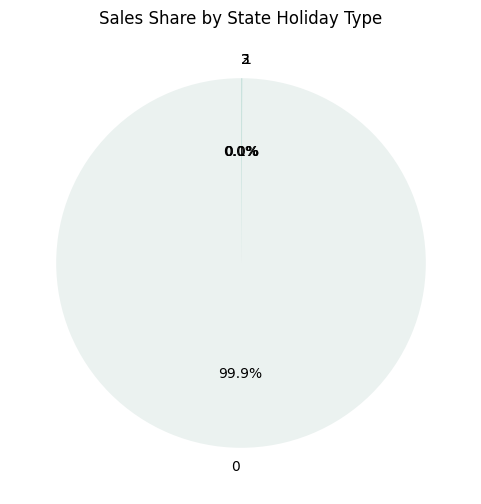

In [28]:
plt.figure(figsize=(6,6))
holiday_sales = train.groupby("StateHoliday")["Sales"].sum()
plt.pie(holiday_sales, labels=holiday_sales.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("light:#5A9"))
plt.title("Sales Share by State Holiday Type")
plt.show()


In [29]:
print("🧾 Columns in train dataset:")
print(train.columns.tolist())


🧾 Columns in train dataset:
['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day']


In [30]:
# Construct a full datetime column from Year, Month, and Day
train["Date"] = pd.to_datetime(train[["Year", "Month", "Day"]])
print("✅ Created 'Date' column successfully.")
display(train[["Store", "Date", "Sales"]].head())


✅ Created 'Date' column successfully.


,Store,Date,Sales
0,1,2015-07-31,5263
1,2,2015-07-31,6064
2,3,2015-07-31,8314
3,4,2015-07-31,13995
4,5,2015-07-31,4822


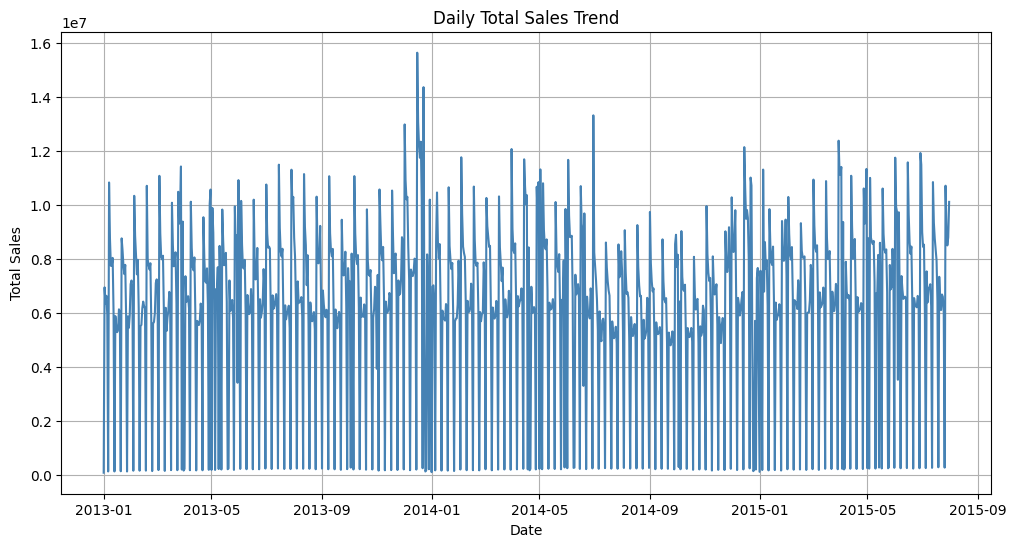

In [31]:
plt.figure(figsize=(12,6))
daily_sales = train.groupby("Date")["Sales"].sum().reset_index()
plt.plot(daily_sales["Date"], daily_sales["Sales"], color="steelblue")
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


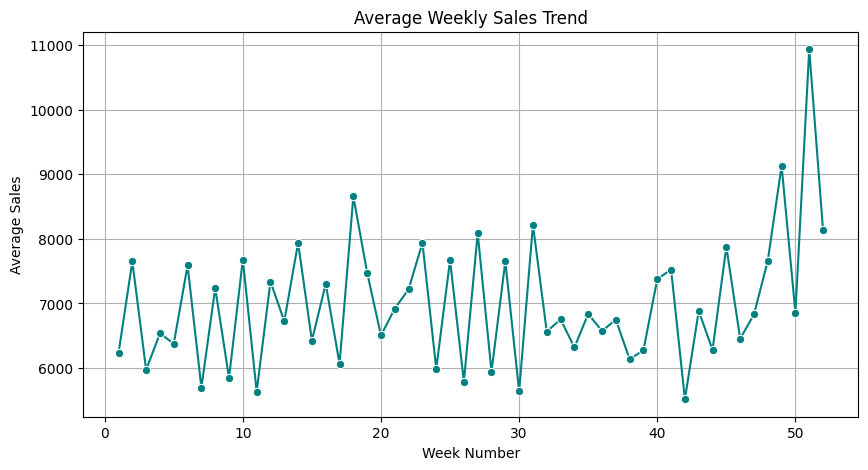

In [32]:
# Derive week number from constructed Date
train["Week"] = train["Date"].dt.isocalendar().week
weekly_sales = train.groupby("Week")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="Week", y="Sales", data=weekly_sales, marker="o", color="teal")
plt.title("Average Weekly Sales Trend")
plt.xlabel("Week Number")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()


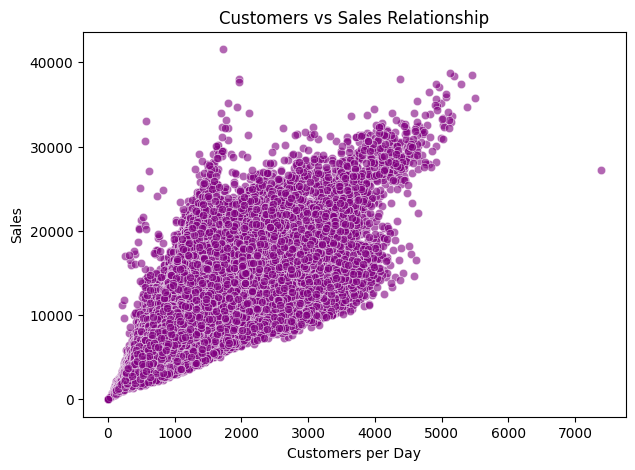

In [33]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Customers", y="Sales", data=train, alpha=0.6, color="purple")
plt.title("Customers vs Sales Relationship")
plt.xlabel("Customers per Day")
plt.ylabel("Sales")
plt.show()


c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


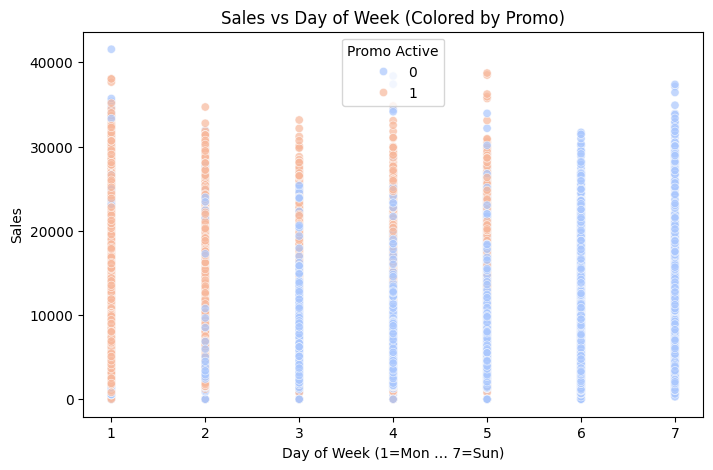

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=train, x="DayOfWeek", y="Sales", hue="Promo", palette="coolwarm", alpha=0.7)
plt.title("Sales vs Day of Week (Colored by Promo)")
plt.xlabel("Day of Week (1=Mon … 7=Sun)")
plt.ylabel("Sales")
plt.legend(title="Promo Active")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\799765075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Month", y="Sales", data=train, palette="Set2")
c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


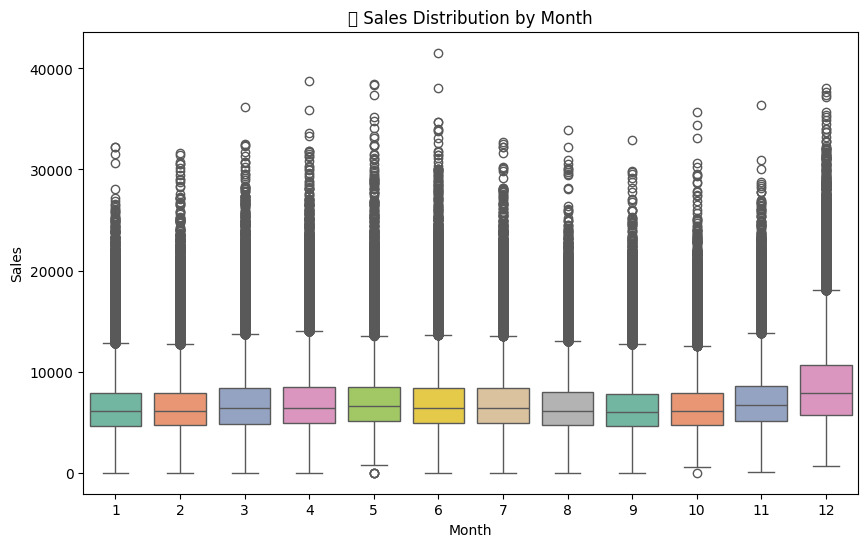

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Month", y="Sales", data=train, palette="Set2")
plt.title("📦 Sales Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\1103140888.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DayOfWeek", y="Sales", data=train, palette="Set3")
c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


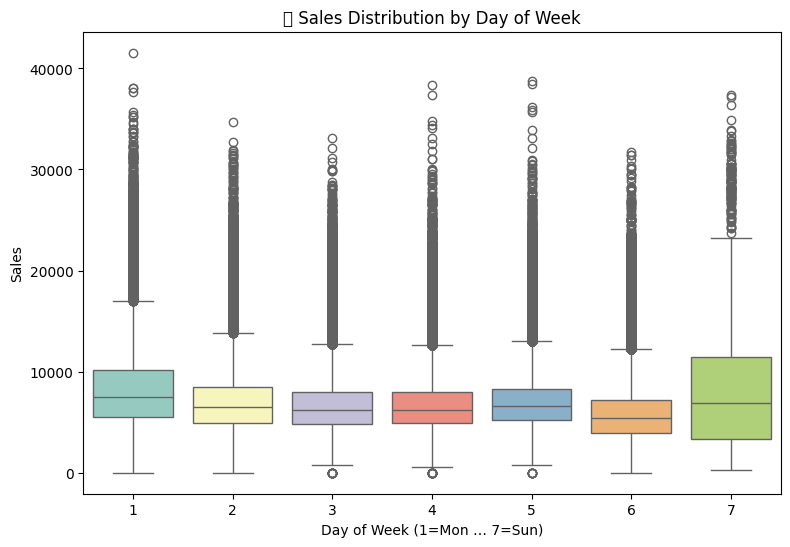

In [36]:
plt.figure(figsize=(9,6))
sns.boxplot(x="DayOfWeek", y="Sales", data=train, palette="Set3")
plt.title("📦 Sales Distribution by Day of Week")
plt.xlabel("Day of Week (1=Mon … 7=Sun)")
plt.ylabel("Sales")
plt.show()


c:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


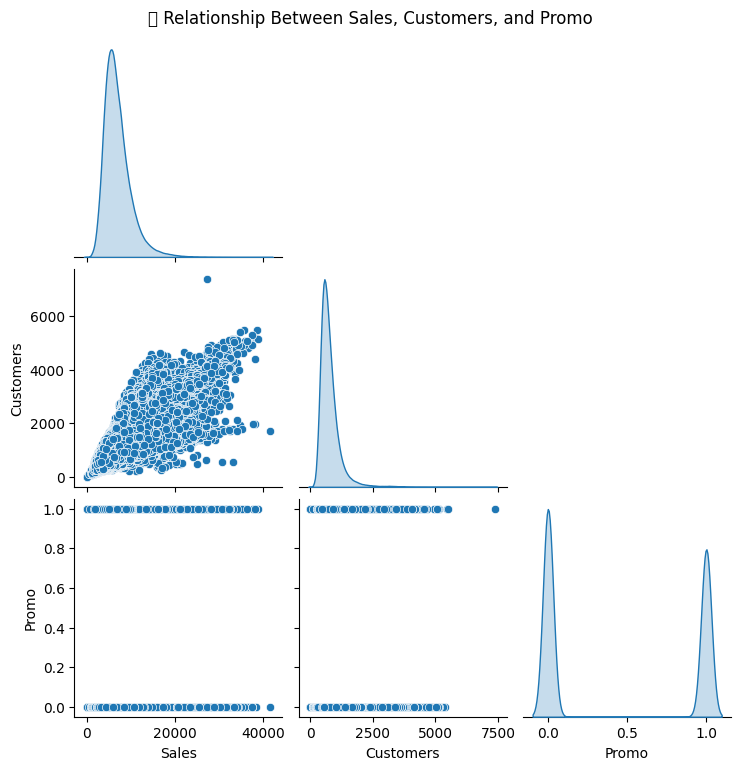

In [37]:
sns.pairplot(train[["Sales", "Customers", "Promo"]], diag_kind="kde", corner=True)
plt.suptitle("🔗 Relationship Between Sales, Customers, and Promo", y=1.02)
plt.show()


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def predict_sales_for_date(date_str, model, base_df):
    """
    Predict sales for all stores on a given date using a trained RandomForest model.
    Provides both technical results and an easy-to-understand narrative + graph.
    """

    # --- Parse and extract date features ---
    date = pd.to_datetime(date_str)
    day_of_week = date.dayofweek + 1  # Monday=0 in Python; dataset uses 1–7
    month = date.month
    year = date.year
    day = date.day

    # --- Prepare input data ---
    input_df = base_df.copy()
    if "DayOfWeek" in input_df.columns:
        input_df["DayOfWeek"] = day_of_week
    if "Month" in input_df.columns:
        input_df["Month"] = month
    if "Year" in input_df.columns:
        input_df["Year"] = year
    if "Day" in input_df.columns:
        input_df["Day"] = day

    # --- Drop extra columns not in model ---
    if hasattr(model, "feature_names_in_"):
        X_input = input_df[model.feature_names_in_]
    else:
        drop_cols = ["Sales", "Customers", "Date", "Week"]
        X_input = input_df.drop(columns=[c for c in drop_cols if c in input_df.columns])

    # --- Predict ---
    preds = model.predict(X_input)
    input_df["Predicted_Sales"] = preds

    # --- Aggregate per store ---
    result = (
        input_df.groupby("Store", as_index=False)
        .agg({"Predicted_Sales": "mean", "Promo": "mean", "Open": "mean"})
        .sort_values(by="Predicted_Sales", ascending=False)
    )

    # --- Summary statistics ---
    top_store = int(result.iloc[0]["Store"])
    top_sales = result.iloc[0]["Predicted_Sales"]
    avg_sales = result["Predicted_Sales"].mean()
    low_store = int(result.iloc[-1]["Store"])
    low_sales = result.iloc[-1]["Predicted_Sales"]

    # --- Human-readable summary ---
    summary_text = f"""
📅 Prediction Summary for {date_str}

Based on the Random Forest forecasting model, Store {top_store} is expected to achieve
the highest sales, averaging around {top_sales:,.2f} units. This is likely influenced
by ongoing promotions or higher customer activity patterns observed in previous data.

On the other hand, Store {low_store} is expected to see relatively lower sales,
around {low_sales:,.2f} units, possibly due to fewer promotions or lower weekday activity.

Across all stores, the average expected sales are approximately {avg_sales:,.2f} units,
indicating a moderately active retail day.

Business Insight: Marketing and supply efforts can be prioritized for high-performing stores
(like Store {top_store}), while strategies such as local promotions or customer engagement
can be considered for lower-performing outlets.
"""
    print(summary_text)

    # --- Visualization ---
    plt.figure(figsize=(10,5))
    sns.barplot(data=result.head(10), x="Store", y="Predicted_Sales", palette="viridis")
    plt.title(f"Top 10 Stores by Predicted Sales on {date_str}", fontsize=14, fontweight="bold")
    plt.xlabel("Store ID")
    plt.ylabel("Predicted Sales")
    plt.tight_layout()
    plt.show()

    return result.reset_index(drop=True)



📅 Prediction Summary for 2015-09-10

Based on the Random Forest forecasting model, Store 1114 is expected to achieve
the highest sales, averaging around 22,073.25 units. This is likely influenced
by ongoing promotions or higher customer activity patterns observed in previous data.

On the other hand, Store 543 is expected to see relatively lower sales,
around 3,044.98 units, possibly due to fewer promotions or lower weekday activity.

Across all stores, the average expected sales are approximately 6,695.52 units,
indicating a moderately active retail day.

Business Insight: Marketing and supply efforts can be prioritized for high-performing stores
(like Store 1114), while strategies such as local promotions or customer engagement
can be considered for lower-performing outlets.



C:\Users\DELL\AppData\Local\Temp\ipykernel_27128\1410407754.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result.head(10), x="Store", y="Predicted_Sales", palette="viridis")


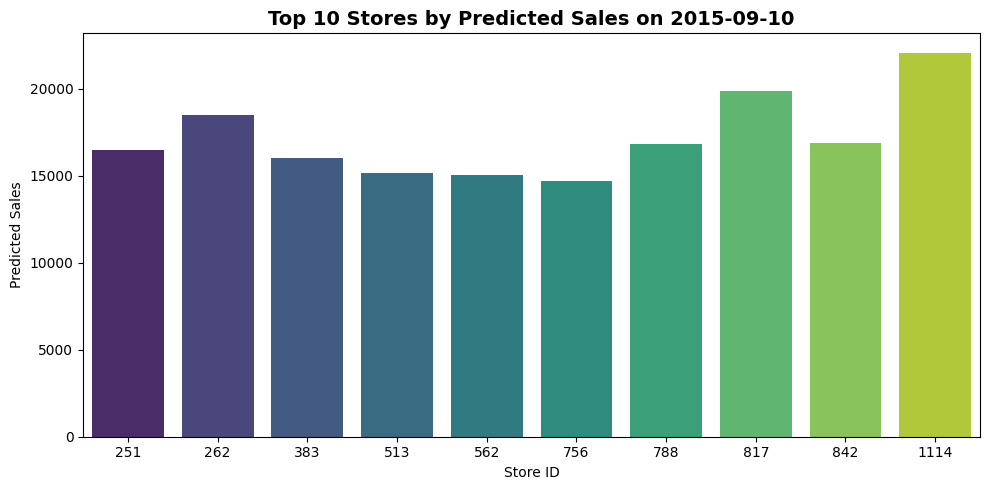

,Store,Predicted_Sales,Promo,Open
0,1114,22073.247411,0.450255,1.0
1,817,19881.588788,0.450255,1.0
2,262,18483.873397,0.382166,1.0
3,842,16865.273215,0.440514,1.0
4,788,16792.650306,0.450255,1.0
5,251,16461.354377,0.449294,1.0
6,383,15987.134141,0.447436,1.0
7,513,15169.525217,0.450255,1.0
8,562,15017.180021,0.382166,1.0
9,756,14674.342195,0.449294,1.0


In [39]:
date_to_predict = "2015-09-10"
predicted_sales_df = predict_sales_for_date(date_to_predict, rf, train)
predicted_sales_df.head(10)


In [40]:
# --- Import joblib (for saving models) ---
import joblib

# --- Save your trained model to a pickle file ---
# Replace `rf` with your model variable name if it’s different
joblib.dump(rf, r"C:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\model.pkl")

print("✅ Model saved successfully at: C:\\Users\\DELL\\OneDrive\\Documents\\Hiya\\07-Coding\\MachineLearning\\RetailForecast\\model.pkl")


✅ Model saved successfully at: C:\Users\DELL\OneDrive\Documents\Hiya\07-Coding\MachineLearning\RetailForecast\model.pkl
